# Notebook 06: Custom Resolution Kernels

This notebook demonstrates loading and using tabulated resolution functions
from Monte Carlo instrument simulations (e.g., McStas, VITESS).

## Prerequisites

```bash
pixi run build
```

## What's New

Previous notebooks used analytical Gaussian resolution (`flight_path_m`,
`delta_t_us`, `delta_l_m`). This notebook uses:

- **`load_resolution(path, flight_path_m)`** — load a tabulated resolution file
- **`apply_resolution(energies, spectrum, resolution)`** — apply tabulated broadening
- **`forward_model(..., resolution=tab)`** — use tabulated resolution in the forward model
- **`fit_spectrum(..., resolution=tab)`** — fit with tabulated resolution in the inner loop

## Resolution File Format

The VENUS/FTS resolution file contains reference kernels R(\u0394t; E_ref) at
discrete energies. Each kernel is stored as (TOF_offset_\u03bcs, weight) pairs.
Kernels are **asymmetric** (moderator pulse shape: sharp rise + exponential tail)
and **peak-normalized** (max weight = 1.0).

```text
FTS BL10 case ...              \u2190 header
-----                           \u2190 separator
   5.00000e-004   0.00000e+000  \u2190 energy block: E_ref (eV)
-53.458917  2.051764e-04        \u2190 (tof_offset_\u03bcs, weight)
-52.415629  2.149833e-04
...                              499 points per block
                                \u2190 blank line separates blocks
   1.00000e-003   0.00000e+000  \u2190 next energy block
...
```

In [1]:
import nereids
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)

## 1. Loading a Resolution File

The resolution file is loaded with `load_resolution(path, flight_path_m)`.
The flight path is needed to convert TOF offsets to energy offsets.

In [2]:
# Look for the VENUS resolution file (not shipped in the repo)
res_path = os.path.join('..', '..', '_fts_bl10_0p5meV_1keV_25pts.txt')
HAS_RESOLUTION = os.path.exists(res_path)

if HAS_RESOLUTION:
    tab = nereids.load_resolution(res_path, flight_path_m=25.0)
    print(tab)
    print(f"  Reference energies: {tab.n_energies}")
    print(f"  Energy range:       {tab.energy_range[0]:.4e} to {tab.energy_range[1]:.4e} eV")
    print(f"  Points per kernel:  {tab.points_per_kernel}")
    print(f"  Flight path:        {tab.flight_path_m} m")
else:
    print(f"Resolution file not found: {res_path}")
    print("This notebook requires an instrument resolution file.")
    print("Skipping remaining cells (expected in CI).")

TabulatedResolution(n_energies=25, range=[5.0000e-4, 1.0000e3] eV, flight_path=25.0 m)
  Reference energies: 25
  Energy range:       5.0000e-04 to 1.0000e+03 eV
  Points per kernel:  499
  Flight path:        25.0 m


## 2. Kernel Shape at Different Energies

The resolution kernel changes shape with energy. At low energies, the
kernel is broad (long TOF, large \u0394t relative to t). At high energies,
it is narrow. The kernels are **asymmetric** due to the moderator
pulse shape.

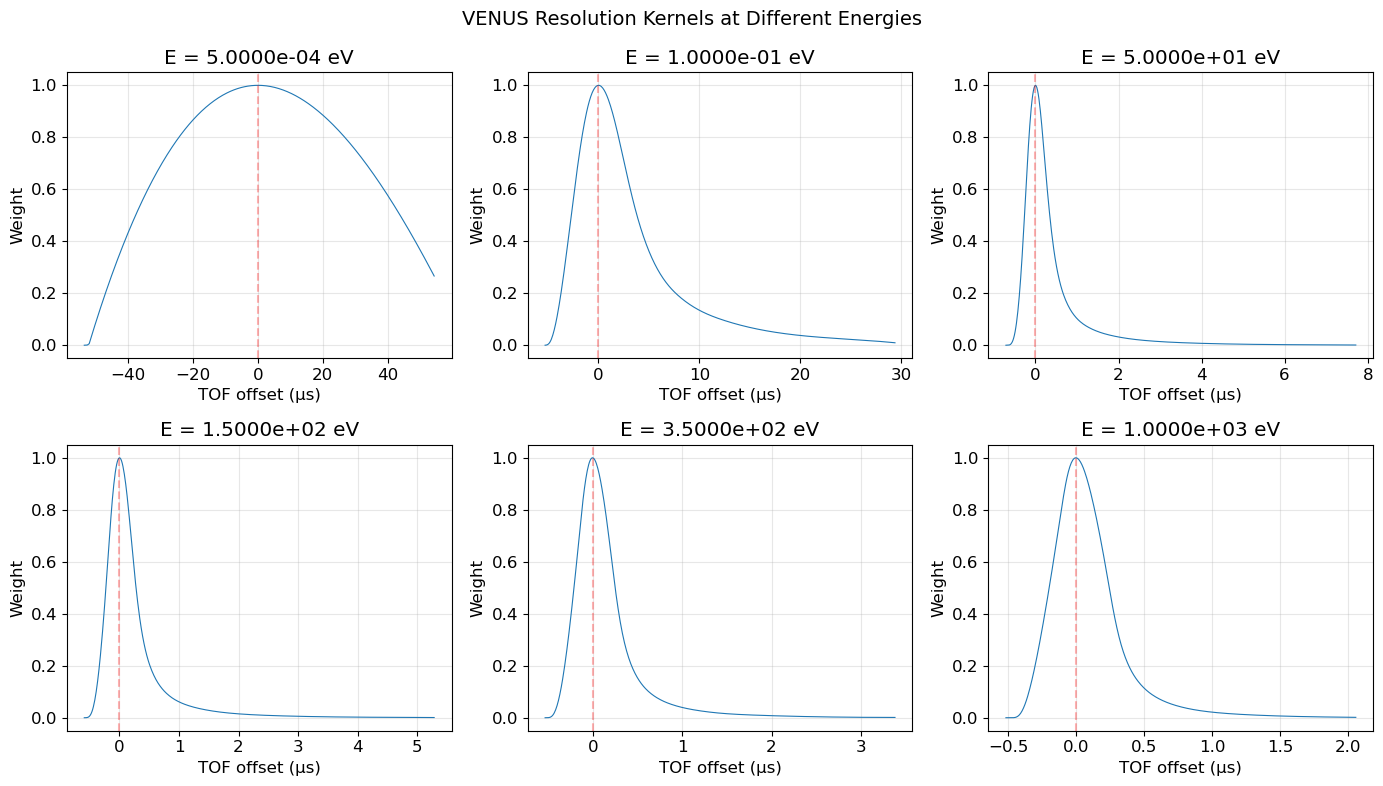

Note: Kernels are asymmetric — sharp rise + exponential tail (moderator pulse shape)


In [3]:
if HAS_RESOLUTION:
    # Read kernels directly from the file to visualize
    with open(res_path) as f:
        text = f.read()
    lines = text.strip().split('\n')
    
    # Parse blocks
    blocks = []
    current_e = None
    offsets, weights = [], []
    for line in lines[2:]:  # skip header + separator
        stripped = line.strip()
        if not stripped:
            if current_e is not None:
                blocks.append((current_e, np.array(offsets), np.array(weights)))
                current_e = None
                offsets, weights = [], []
            continue
        parts = stripped.split()
        if len(parts) != 2:
            continue
        x, y = float(parts[0]), float(parts[1])
        if current_e is None:
            current_e = x
        else:
            offsets.append(x)
            weights.append(y)
    if current_e is not None:
        blocks.append((current_e, np.array(offsets), np.array(weights)))
    
    # Plot kernels at selected energies
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    indices = [0, 5, 10, 15, 20, 24]  # sample across the 25 reference energies
    
    for ax, idx in zip(axes.flat, indices):
        if idx < len(blocks):
            e, off, w = blocks[idx]
            ax.plot(off, w, linewidth=0.8)
            ax.set_title(f'E = {e:.4e} eV')
            ax.set_xlabel('TOF offset (\u03bcs)')
            ax.set_ylabel('Weight')
            ax.grid(True, alpha=0.3)
            # Mark the peak
            peak_idx = np.argmax(w)
            ax.axvline(off[peak_idx], color='r', alpha=0.3, linestyle='--')
    
    fig.suptitle('VENUS Resolution Kernels at Different Energies', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print(f"Note: Kernels are asymmetric — sharp rise + exponential tail (moderator pulse shape)")

## 3. Gaussian vs Tabulated Resolution

The analytical Gaussian approximation is symmetric, while the real instrument
kernel is asymmetric. Let's compare their effect on a U-238 transmission
spectrum.

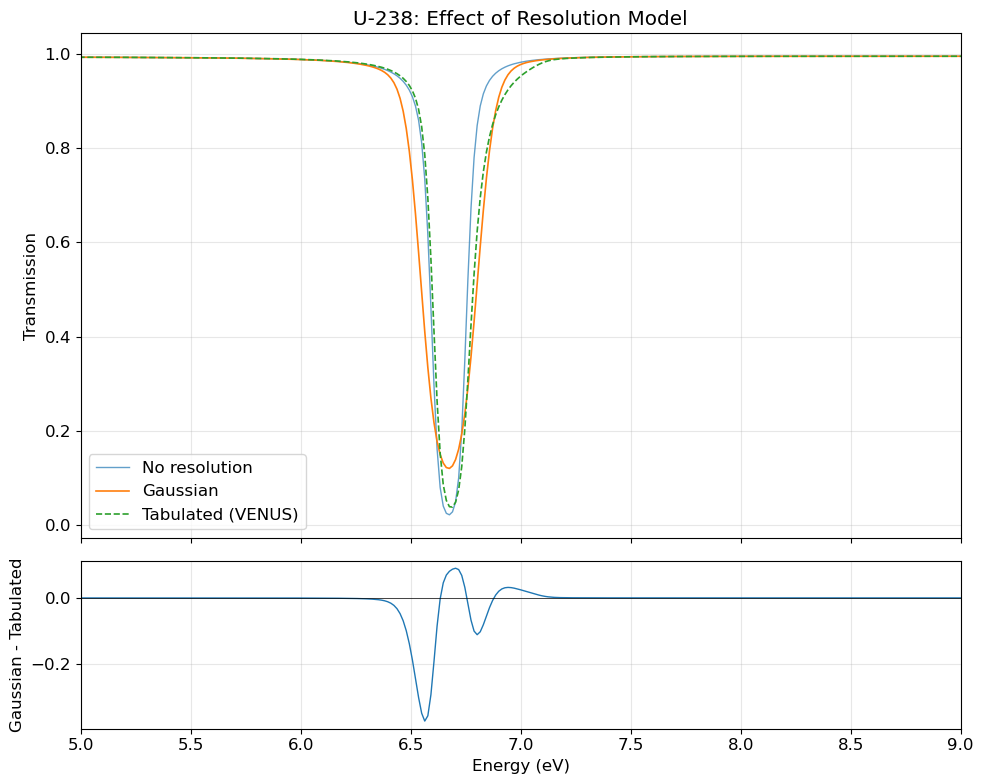

Max |Gaussian - Tabulated|: 0.3754


In [4]:
if HAS_RESOLUTION:
    u238 = nereids.create_resonance_data(
        z=92, a=238, awr=236.006, scattering_radius=9.4285,
        resonances=[(6.674, 0.5, 1.493e-3, 23.0e-3)]
    )
    
    energies = np.linspace(1.0, 15.0, 1000)
    density = 0.0005
    
    # No resolution
    T_none = nereids.forward_model(energies, [(u238, density)], temperature_k=300.0)
    
    # Gaussian resolution
    T_gauss = nereids.forward_model(energies, [(u238, density)], temperature_k=300.0,
                                     flight_path_m=25.0, delta_t_us=5.0, delta_l_m=0.01)
    
    # Tabulated resolution
    T_tab = nereids.forward_model(energies, [(u238, density)], temperature_k=300.0,
                                   resolution=tab)
    
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    
    ax = axes[0]
    ax.plot(energies, T_none, label='No resolution', linewidth=1.0, alpha=0.7)
    ax.plot(energies, T_gauss, label='Gaussian', linewidth=1.2)
    ax.plot(energies, T_tab, '--', label='Tabulated (VENUS)', linewidth=1.2)
    ax.set_ylabel('Transmission')
    ax.set_title('U-238: Effect of Resolution Model')
    ax.legend()
    ax.set_xlim(5, 9)
    ax.grid(True, alpha=0.3)
    
    ax = axes[1]
    ax.plot(energies, np.asarray(T_gauss) - np.asarray(T_tab), linewidth=1.0)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_xlabel('Energy (eV)')
    ax.set_ylabel('Gaussian - Tabulated')
    ax.set_xlim(5, 9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Max |Gaussian - Tabulated|: {np.max(np.abs(np.asarray(T_gauss) - np.asarray(T_tab))):.4f}")

## 4. Fitting with Tabulated Resolution

When the data was generated with the tabulated kernel, fitting with the
**same** tabulated kernel recovers the correct density. Fitting with a
Gaussian approximation or no resolution introduces bias.

In [5]:
if HAS_RESOLUTION:
    true_density = 0.0005
    noise_level = 0.01
    
    # Generate data with tabulated resolution
    T_true_tab = np.asarray(nereids.forward_model(
        energies, [(u238, true_density)], temperature_k=300.0, resolution=tab
    ))
    noise = np.random.normal(0, noise_level, len(energies))
    T_measured = T_true_tab + noise
    sigma = np.full_like(T_measured, noise_level)
    
    # Fit with tabulated resolution (correct model)
    r_tab = nereids.fit_spectrum(T_measured, sigma, energies, [u238],
                                 temperature_k=300.0, resolution=tab)
    
    # Fit with Gaussian resolution (approximate)
    r_gauss = nereids.fit_spectrum(T_measured, sigma, energies, [u238],
                                   temperature_k=300.0,
                                   flight_path_m=25.0, delta_t_us=5.0, delta_l_m=0.01)
    
    # Fit without resolution (wrong)
    r_none = nereids.fit_spectrum(T_measured, sigma, energies, [u238],
                                  temperature_k=300.0)
    
    print(f"True density: {true_density:.6f} atoms/barn")
    print()
    fmt = "{:>22}  {:>12}  {:>10}  {:>8}"
    print(fmt.format('Model', 'Density', 'Error', 'chi2_red'))
    print('-' * 58)
    for name, r in [('Tabulated (correct)', r_tab), ('Gaussian (approx)', r_gauss), ('No resolution', r_none)]:
        err = abs(r.densities[0] - true_density) / true_density * 100
        print(fmt.format(name, f'{r.densities[0]:.6f}', f'{err:.1f}%', f'{r.reduced_chi_squared:.3f}'))

True density: 0.000500 atoms/barn

                 Model       Density       Error  chi2_red
----------------------------------------------------------
   Tabulated (correct)      0.000499        0.3%     0.959
     Gaussian (approx)      0.000376       24.8%     7.054
         No resolution      0.000596       19.1%     4.915


## 5. Standalone `apply_resolution()`

The `apply_resolution()` function lets you apply tabulated broadening to
any spectrum — cross-sections, transmission, or arbitrary data. This is
useful for post-processing or comparing different resolution models.

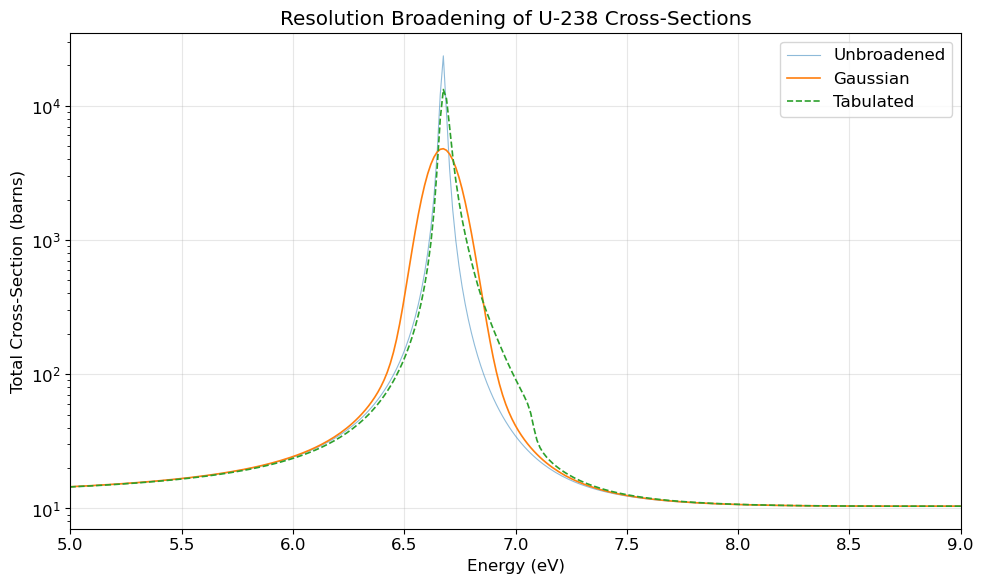

Peak unbroadened: 23516 barns
Peak Gaussian:    4783 barns
Peak Tabulated:   13206 barns


In [6]:
if HAS_RESOLUTION:
    # Get unbroadened cross-sections
    xs = nereids.cross_sections(energies, u238)
    xs_total = np.asarray(xs['total'])
    
    # Apply tabulated resolution
    xs_broadened = nereids.apply_resolution(energies, xs_total, tab)
    
    # Apply Gaussian resolution for comparison
    xs_gauss = nereids.resolution_broaden(energies, xs_total, 25.0, 5.0, 0.01)
    
    fig, ax = plt.subplots()
    ax.semilogy(energies, xs_total, label='Unbroadened', linewidth=0.8, alpha=0.5)
    ax.semilogy(energies, xs_gauss, label='Gaussian', linewidth=1.2)
    ax.semilogy(energies, xs_broadened, '--', label='Tabulated', linewidth=1.2)
    ax.set_xlabel('Energy (eV)')
    ax.set_ylabel('Total Cross-Section (barns)')
    ax.set_title('Resolution Broadening of U-238 Cross-Sections')
    ax.legend()
    ax.set_xlim(5, 9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Peak unbroadened: {np.max(xs_total):.0f} barns")
    print(f"Peak Gaussian:    {np.max(np.asarray(xs_gauss)):.0f} barns")
    print(f"Peak Tabulated:   {np.max(np.asarray(xs_broadened)):.0f} barns")

## Summary

This notebook demonstrated:

1. **`load_resolution(path, flight_path_m)`** — load tabulated kernels from Monte Carlo simulations
2. **Kernel visualization** — asymmetric profiles that vary with energy
3. **Gaussian vs Tabulated** — the symmetric Gaussian approximation misses asymmetry
4. **Fitting with tabulated resolution** — correct model recovers exact density;
   Gaussian approximation and no-resolution fits are biased
5. **`apply_resolution()`** — standalone broadening for arbitrary spectra

### File Format

NEREIDS reads the VENUS/FTS format: a header line, separator, then energy
blocks separated by blank lines. Each block starts with an energy marker
followed by (TOF_offset_\u03bcs, weight) pairs.

For custom instruments, generate a file in the same format from your
Monte Carlo simulation (McStas, VITESS, etc.).

**Previous**: [01_endf_loading.ipynb](01_endf_loading.ipynb) — ENDF data retrieval